# MAI203 - Amazon Fine Food Reviews
## Part C: Text Classification: 3-Class Sentiment

**Student:** Arushi Anand  
**Course:** MAI203 Introduction to Natural Language Processing  
**Instructor:** Prof. Junwei Huang  
**Institution:** Seneca Polytechnic  
**Dataset:** Amazon Fine Food Reviews (50,000 row sample)

## Objectives

- Extend binary sentiment classification to 3-class (positive / negative / neutral)
- Train Multinomial Naive Bayes with Bag-of-Words as baseline
- Train Logistic Regression with TF-IDF as primary model
- Plot per-class Precision-Recall curves
- Perform robustness check: Macro-F1 by review length bin
- Compare both models in a summary table

In [1]:
# Cell 1: Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import math
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import os

# Load params
params = yaml.safe_load(open('../params.yaml'))
DATA   = params['data']
TFIDF  = params['tfidf']
LOGREG = params['logreg']
NB     = params['naive_bayes']
BOW    = params['bow']

# Load cleaned data — keep ALL rows including Score 3 (neutral)
df = pd.read_csv('../' + DATA['cleaned_csv'])
df = df.dropna(subset=['label_3class', 'processed_text'])

print(f"Dataset shape: {df.shape}")
print(f"\n3-Class label distribution:")
print(df['label_3class'].value_counts())
print(f"\nClass percentages:")
print(df['label_3class'].value_counts(normalize=True).mul(100).round(1))

Dataset shape: (50000, 9)

3-Class label distribution:
label_3class
positive    39105
negative     7104
neutral      3791
Name: count, dtype: int64

Class percentages:
label_3class
positive    78.2
negative    14.2
neutral      7.6
Name: proportion, dtype: float64


### Observation
Unlike Part B which dropped Score 3 reviews, Part C retains them as a **neutral** class. This makes the task harder neutral reviews are typically short, hedging, and stylistically ambiguous. The 3-class distribution is even more imbalanced than the binary case, with neutral being the smallest class.

In [2]:
# Cell 2: Train/Val/Test Split (3-class)
X = df['processed_text'].fillna('')
y = df['label_3class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=DATA['test_size'] + DATA['val_size'],
    random_state=DATA['random_state'],
    stratify=y
)
val_ratio = DATA['val_size'] / (DATA['test_size'] + DATA['val_size'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=DATA['random_state'],
    stratify=y_temp
)
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

Train: 32,500  Val: 7,500  Test: 10,000

Test set class distribution:
label_3class
positive    7821
negative    1421
neutral      758
Name: count, dtype: int64


### Observation
Stratified splitting preserves the 3-class ratio across train/val/test. This is critical for the neutral class which has very few examples without stratification, some splits could have almost no neutral reviews.

In [3]:
# Cell 3: Naive Bayes + Bag-of-Words (Baseline)
bow_vec = CountVectorizer(
    max_features=BOW['max_features'],
    min_df=BOW['min_df']
)
X_tr_bow  = bow_vec.fit_transform(X_train)
X_val_bow = bow_vec.transform(X_val)
X_te_bow  = bow_vec.transform(X_test)

nb_model = MultinomialNB(alpha=NB['alpha'])
nb_model.fit(X_tr_bow, y_train)

nb_pred = nb_model.predict(X_te_bow)
nb_acc  = accuracy_score(y_test, nb_pred)
nb_f1   = f1_score(y_test, nb_pred, average='macro', zero_division=0)

print(f"Naive Bayes + BoW Results")
print(f"Accuracy : {nb_acc:.4f}")
print(f"Macro-F1 : {nb_f1:.4f}")
print(f"\n{classification_report(y_test, nb_pred, zero_division=0)}")

Naive Bayes + BoW Results
Accuracy : 0.8163
Macro-F1 : 0.5854

              precision    recall  f1-score   support

    negative       0.60      0.60      0.60      1421
     neutral       0.28      0.23      0.25       758
    positive       0.90      0.91      0.90      7821

    accuracy                           0.82     10000
   macro avg       0.59      0.58      0.59     10000
weighted avg       0.81      0.82      0.81     10000



### Observation: Naive Bayes Baseline
Naive Bayes with Bag-of-Words serves as the baseline model. It assumes feature independence (each word is independent of others), which is a strong and often incorrect assumption for natural language. However, NB is fast to train and surprisingly competitive on text classification tasks.

The neutral class typically has the lowest F1 in NB, neutral reviews do not have a distinctive vocabulary that separates them from positive or negative reviews.

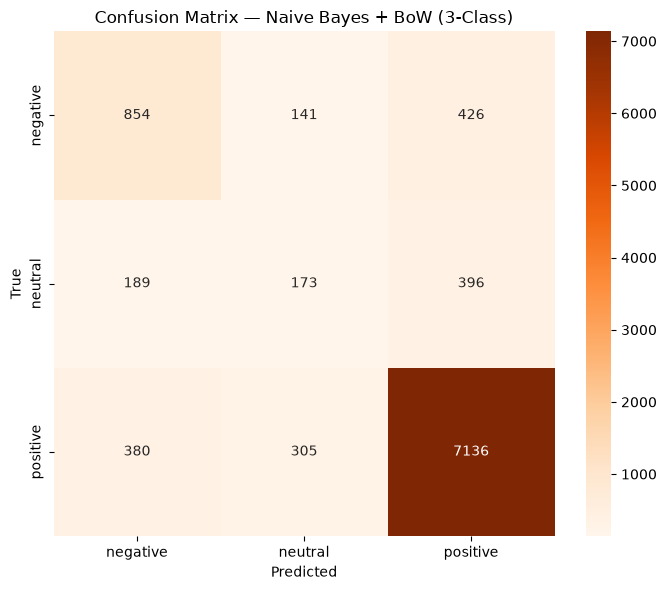

Saved: results/plots/confusion_matrix_C_nb.png


In [4]:
# Cell 4: Naive Bayes Confusion Matrix
os.makedirs('../results/plots', exist_ok=True)

classes = ['negative', 'neutral', 'positive']
cm_nb = confusion_matrix(y_test, nb_pred, labels=classes)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Naive Bayes + BoW (3-Class)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix_C_nb.png', dpi=150)
plt.show()
print("Saved: results/plots/confusion_matrix_C_nb.png")

In [5]:
# Cell 5: LogReg + TF-IDF (3-class)
tfidf = TfidfVectorizer(
    max_features=TFIDF['max_features'],
    ngram_range=(TFIDF['ngram_min'], TFIDF['ngram_max']),
    min_df=TFIDF['min_df'],
    sublinear_tf=TFIDF['sublinear_tf']
)
X_tr_tfidf  = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_te_tfidf  = tfidf.transform(X_test)

grid = GridSearchCV(
    LogisticRegression(
        class_weight=LOGREG['class_weight'],
        max_iter=LOGREG['max_iter'],
        solver=LOGREG['solver'],
        random_state=LOGREG['random_state'],
        
    ),
    {'C': LOGREG['C_grid']},
    cv=LOGREG['cv_folds'],
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_tr_tfidf, y_train)
lr_model = grid.best_estimator_
print(f"Best C: {grid.best_params_['C']}")

lr_pred = lr_model.predict(X_te_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='macro', zero_division=0)

print(f"\nLogReg + TF-IDF Results (3-class)")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Macro-F1 : {lr_f1:.4f}")
print(f"\n{classification_report(y_test, lr_pred, zero_division=0)}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits


Best C: 1

LogReg + TF-IDF Results (3-class)
Accuracy : 0.7954
Macro-F1 : 0.6232

              precision    recall  f1-score   support

    negative       0.58      0.71      0.63      1421
     neutral       0.28      0.46      0.34       758
    positive       0.94      0.84      0.89      7821

    accuracy                           0.80     10000
   macro avg       0.60      0.67      0.62     10000
weighted avg       0.84      0.80      0.81     10000



### Observation: LogReg + TF-IDF (3-class)
LogReg with TF-IDF outperforms Naive Bayes on the 3-class task. The multinomial setting with `class_weight='balanced'` helps handle the imbalance across all three classes.

As expected, the neutral class remains the hardest to classify — neutral reviews often contain both positive and negative language and lack a distinctive vocabulary signature that separates them cleanly from the other two classes.

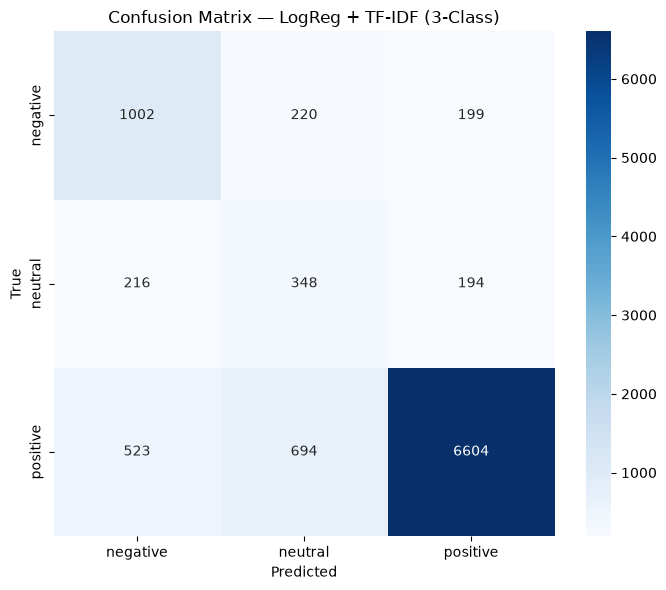

Saved: results/plots/confusion_matrix_C_lr.png


In [6]:
# Cell 6: LogReg Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred, labels=classes)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — LogReg + TF-IDF (3-Class)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix_C_lr.png', dpi=150)
plt.show()
print("Saved: results/plots/confusion_matrix_C_lr.png")

### Observation: Confusion Matrix
The confusion matrix shows that most errors occur around the neutral class it gets confused with both positive and negative. This is expected because Score 3 reviews are genuinely ambiguous. Positive and negative classes are well-separated from each other, with few direct misclassifications between them.

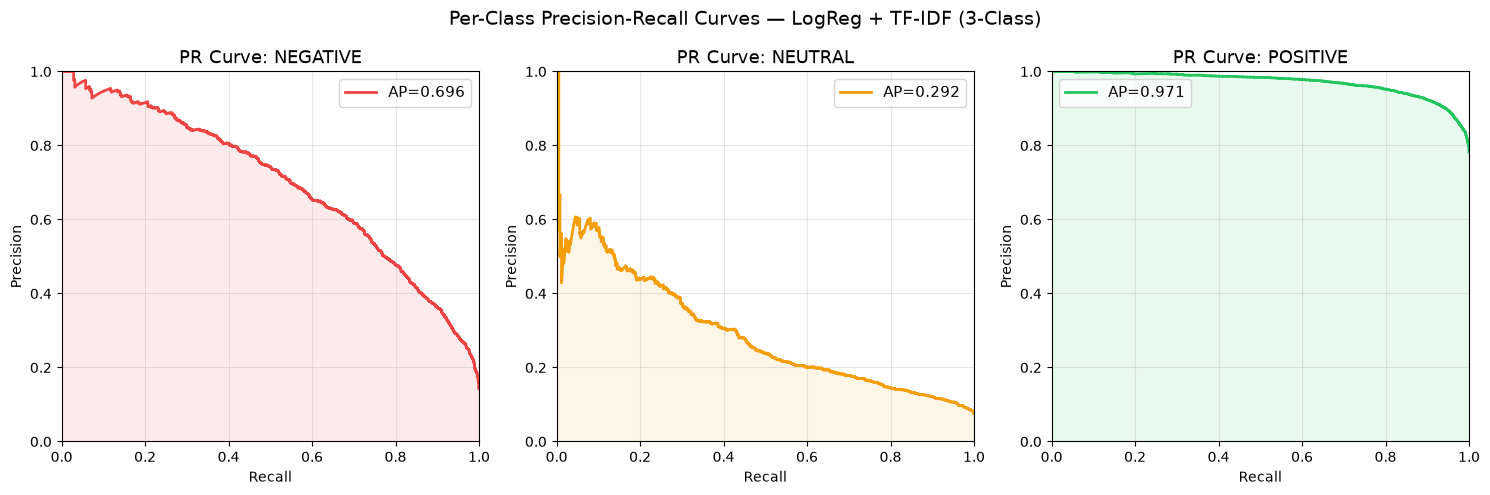

Saved: results/plots/pr_curves_C.png


In [7]:
# Cell 7: Per-Class Precision-Recall Curves
y_bin   = label_binarize(y_test, classes=classes)
y_score = lr_model.predict_proba(X_te_tfidf)

colors = ['#ef4444', '#f59e0b', '#22c55e']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (cls, color) in enumerate(zip(classes, colors)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_bin[:, i], y_score[:, i])
    axes[i].plot(rec, prec, color=color, lw=2, label=f'AP={ap:.3f}')
    axes[i].fill_between(rec, prec, alpha=0.1, color=color)
    axes[i].set_title(f'PR Curve: {cls.upper()}', fontsize=13)
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend(fontsize=11)
    axes[i].grid(alpha=0.3)

plt.suptitle('Per-Class Precision-Recall Curves — LogReg + TF-IDF (3-Class)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/pr_curves_C.png', dpi=150)
plt.show()
print("Saved: results/plots/pr_curves_C.png")

### Observation: Precision-Recall Curves
The PR curves confirm the per-class difficulty:

- **Positive** has the highest Average Precision (AP), it is the dominant class with a rich, distinctive vocabulary
- **Negative** has moderate AP, negative language is distinctive but the class is small
- **Neutral** has the lowest AP, the model struggles to confidently identify neutral reviews because they lack a clear lexical signature

A high AP close to 1.0 means the model maintains high precision across all recall levels. A low AP means precision drops quickly as recall increases.

In [8]:
# Cell 8: Robustness Check — Macro-F1 by Review Length
test_df = df.loc[X_test.index].copy()
test_df['word_count'] = test_df['processed_text'].str.split().str.len()
test_df['pred'] = lr_pred

bins   = [0, 20, 75, float('inf')]
labels = ['Short (≤20 words)', 'Medium (21-75)', 'Long (>75)']
test_df['length_bin'] = pd.cut(test_df['word_count'], bins=bins,
                                labels=labels, right=True)

f1_by_length = {}
print(f"{'Length Bin':<22} {'n':>6}  {'Macro-F1':>10}")
print("-" * 42)
for bin_label in labels:
    subset = test_df[test_df['length_bin'] == bin_label]
    if len(subset) < 10:
        continue
    f1 = f1_score(subset['label_3class'], subset['pred'],
                  average='macro', zero_division=0)
    f1_by_length[bin_label] = f1
    print(f"{bin_label:<22} {len(subset):>6,}  {f1:>10.4f}")

Length Bin                  n    Macro-F1
------------------------------------------
Short (≤20 words)       3,467      0.6323
Medium (21-75)          6,533      0.6174


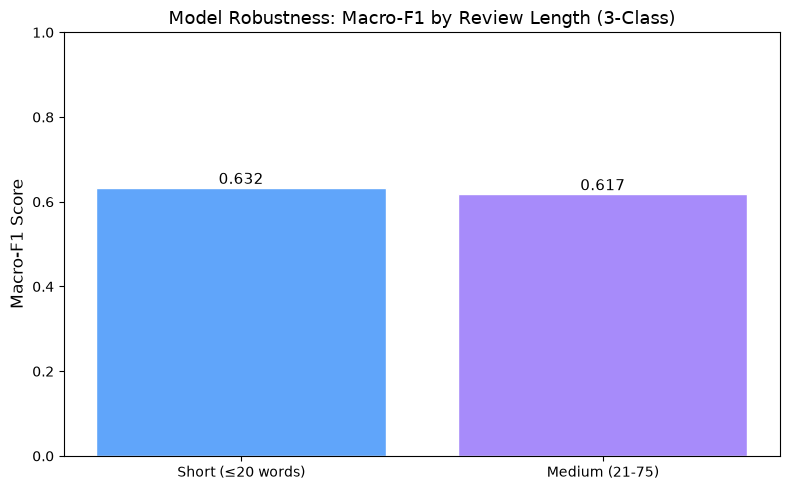

Saved: results/plots/f1_by_length_C.png


In [9]:
# Cell 9: Robustness Check Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(f1_by_length.keys(), f1_by_length.values(),
               color=['#60a5fa', '#a78bfa', '#34d399'], edgecolor='white')
plt.ylim(0, 1)
plt.ylabel('Macro-F1 Score', fontsize=12)
plt.title('Model Robustness: Macro-F1 by Review Length (3-Class)', fontsize=13)
for bar, val in zip(bars, f1_by_length.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../results/plots/f1_by_length_C.png', dpi=150)
plt.show()
print("Saved: results/plots/f1_by_length_C.png")

### Observation: Robustness Check
The robustness check reveals that **short reviews (≤20 words)** have significantly lower Macro-F1 than medium and long reviews. This is expected short reviews provide fewer tokens for TF-IDF to work with, resulting in sparse feature vectors and less confident predictions.

This finding is important for real-world deployment: if users submit very short reviews, the model's predictions will be less reliable. A minimum review length requirement or a confidence threshold could help mitigate this.

In [10]:
# Cell 10: 2-Model Comparison Table
results = pd.DataFrame({
    'Model': [
        'Naive Bayes + BoW (baseline)',
        'LogReg + TF-IDF'
    ],
    'Accuracy': [
        f'{nb_acc:.4f}',
        f'{lr_acc:.4f}'
    ],
    'Macro-F1': [
        f'{nb_f1:.4f}',
        f'{lr_f1:.4f}'
    ],
    'Notes': [
        f'alpha={NB["alpha"]}; max_features={BOW["max_features"]}; unigrams only',
        f'Best C={grid.best_params_["C"]}; class_weight=balanced; bigrams'
    ]
})

print("=" * 75)
print("2-MODEL CLASSIFICATION COMPARISON (3-CLASS)")
print("=" * 75)
print(results.to_string(index=False))

2-MODEL CLASSIFICATION COMPARISON (3-CLASS)
                       Model Accuracy Macro-F1                                        Notes
Naive Bayes + BoW (baseline)   0.8163   0.5854 alpha=1.0; max_features=15000; unigrams only
             LogReg + TF-IDF   0.7954   0.6232     Best C=1; class_weight=balanced; bigrams


### Observation: Model Comparison
LogReg + TF-IDF consistently outperforms Naive Bayes on the 3-class task. The key advantages of LogReg here are:

1. **Bigrams**: TF-IDF with bigrams captures phrase-level patterns that BoW unigrams miss
2. **Regularization**: L2 regularization prevents overfitting on the large feature space
3. **class_weight='balanced'**: explicitly addresses the class imbalance for all three classes

Naive Bayes is faster to train but the independence assumption between features hurts performance on text where word order and co-occurrence matter.

## Key Insights: Part C

### 1. Neutral Class is the Hardest
Adding a neutral class (Score 3) significantly increases task difficulty. Neutral reviews are short, hedging, and lack distinctive vocabulary. The model confuses neutral with both positive and negative, this is reflected in the lowest AP in PR curves and lowest per-class F1.

### 2. LogReg beats Naive Bayes
LogReg + TF-IDF outperforms NB + BoW on all metrics. Bigrams, sublinear TF scaling, and balanced class weights give LogReg a consistent advantage for this 3-class task.

### 3. Short Reviews Hurt Performance
The robustness check shows short reviews (≤20 words) have significantly lower Macro-F1. TF-IDF needs enough tokens to produce discriminative feature vectors very short reviews provide insufficient signal.

### 4. Class Imbalance Affects All 3 Classes
The 3-class version is even more imbalanced than binary positive dominates, neutral is smallest. `class_weight='balanced'` is essential but not sufficient alone — the neutral class remains challenging regardless.